# Ptoject 1 Web Scraping Airbnb Page

Κωνσταντίνα Μαρίνα Μπλέτσα, ΑΕΜ 243
Μαρία Καρλάκη, ΑΕΜ 244

# Cleaning Raw Data - Preprocessing

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("airbnb_listings_raw.csv")
df.head()

,area,room_url,price_per_nigh,guests,beds,bedrooms,baths,superhost,guest_favourite,review_index,number_of_reviews,host_name,characteristics,latitude,longitude
0,Ampelokipoi-Menemeni,https://www.airbnb.gr/rooms/100921038498040067...,52.80,2,1.0,NaN,1,No,No,"4,52",100.0,Halu,NaN,40.61738,22.96212
1,Ampelokipoi-Menemeni,https://www.airbnb.gr/rooms/106680853911906599...,47.00,4,3.0,1.0,1,No,No,"3,92",13.0,Damia,Check-in χωρίς παρουσία οικοδεσπότη | Θέα: πόλ...,40.65278,22.91245
2,Ampelokipoi-Menemeni,https://www.airbnb.gr/rooms/106689444877383509...,47.00,2,1.0,1.0,1,No,No,"4,6",10.0,Damia,Check-in χωρίς παρουσία οικοδεσπότη | Θέα: πόλ...,40.65082,22.91199
3,Ampelokipoi-Menemeni,https://www.airbnb.gr/rooms/106831973408269169...,46.53,2,1.0,1.0,1,No,No,"4,46",41.0,Damia,Πολύ καλή εμπειρία άφιξης | Check-in χωρίς παρ...,40.65102,22.91265
4,Ampelokipoi-Menemeni,https://www.airbnb.gr/rooms/107050705237718786...,50.53,3,2.0,1.0,1,No,No,"4,66",29.0,Damia,Check-in χωρίς παρουσία οικοδεσπότη | Θέα: πόλ...,40.65281,22.91256


In [4]:
df.duplicated(subset=["latitude", "longitude","price_per_nigh", "beds", "guests", "baths"]).sum()

np.int64(260)

In [5]:
df = df.drop_duplicates(subset=["latitude", "longitude","price_per_nigh", "beds", "guests", "baths"])

In [6]:
df.rename(columns={"price_per_nigh": "price"}, inplace=True)
df.rename(columns={"number_of_reviews": "reviews"}, inplace=True)
df.rename(columns={"guest_favourite": "favourite"}, inplace=True)
df.rename(columns={"review_index": "rating"}, inplace=True)

In [7]:
df.drop(columns=["host_name", "room_url"], inplace=True)

In [8]:
df = pd.get_dummies(df, columns=["area"])

df['area_Ampelokipoi-Menemeni'] = df['area_Ampelokipoi-Menemeni'].astype(int)
df['area_Evosmos'] = df['area_Evosmos'].astype(int)
df['area_Stavroupoli'] = df['area_Stavroupoli'].astype(int)

In [9]:
df['bedrooms'] = df['bedrooms'].fillna(0)

In [10]:
df['superhost'] = df['superhost'].map({'Yes': 1, 'No': 0})
df['favourite'] = df['favourite'].map({'Yes': 1, 'No': 0})

In [11]:
df["characteristics"] = df["characteristics"].fillna("").str.lower()

df["parking"] = df["characteristics"].str.contains("πάρκινγκ").astype(int)
df["view"] = df["characteristics"].str.contains("θέα").astype(int)
df["self_checkin"] = df["characteristics"].str.contains("χωρίς παρουσία").astype(int)

df[["characteristics", "parking", "view", "self_checkin"]].head(10)

,characteristics,parking,view,self_checkin
0,,0,0,0
1,check-in χωρίς παρουσία οικοδεσπότη | θέα: πόλ...,1,1,1
2,check-in χωρίς παρουσία οικοδεσπότη | θέα: πόλ...,0,1,1
3,πολύ καλή εμπειρία άφιξης | check-in χωρίς παρ...,0,1,1
4,check-in χωρίς παρουσία οικοδεσπότη | θέα: πόλ...,0,1,1
5,check-in χωρίς παρουσία οικοδεσπότη | ο/η urba...,0,0,1
6,check-in χωρίς παρουσία οικοδεσπότη,0,0,1
7,εξαιρετική εμπειρία άφιξης,0,0,0
8,πολύ καλή εμπειρία άφιξης | check-in χωρίς παρ...,0,0,1
9,check-in χωρίς παρουσία οικοδεσπότη | ο/η hris...,0,0,1


In [12]:
df.drop(columns=["characteristics"], inplace=True)

In [13]:
df["baths"] = df["baths"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df["rating"] = df["rating"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [14]:
df["rating"].fillna(df["rating"].mean(), inplace=True)
df["reviews"].fillna(0, inplace=True)

/tmp/ipykernel_7190/1506101108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].mean(), inplace=True)
/tmp/ipykernel_7190/1506101108.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [15]:
df.to_csv("airbnb_clean_data.csv", index=False)

In [16]:
df = pd.read_csv("airbnb_clean_data.csv")
df.head()

,price,guests,beds,bedrooms,baths,superhost,favourite,rating,reviews,latitude,longitude,area_Ampelokipoi-Menemeni,area_Evosmos,area_Stavroupoli,parking,view,self_checkin
0,52.80,2,1.0,0.0,1.0,0,0,4.0,100.0,40.61738,22.96212,1,0,0,0,0,0
1,47.00,4,3.0,1.0,1.0,0,0,3.0,13.0,40.65278,22.91245,1,0,0,1,1,1
2,47.00,2,1.0,1.0,1.0,0,0,4.0,10.0,40.65082,22.91199,1,0,0,0,1,1
3,46.53,2,1.0,1.0,1.0,0,0,4.0,41.0,40.65102,22.91265,1,0,0,0,1,1
4,50.53,3,2.0,1.0,1.0,0,0,4.0,29.0,40.65281,22.91256,1,0,0,0,1,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      280 non-null    float64
 1   guests                     280 non-null    int64  
 2   beds                       279 non-null    float64
 3   bedrooms                   280 non-null    float64
 4   baths                      279 non-null    float64
 5   superhost                  280 non-null    int64  
 6   favourite                  280 non-null    int64  
 7   rating                     280 non-null    float64
 8   reviews                    280 non-null    float64
 9   latitude                   280 non-null    float64
 10  longitude                  280 non-null    float64
 11  area_Ampelokipoi-Menemeni  280 non-null    int64  
 12  area_Evosmos               280 non-null    int64  
 13  area_Stavroupoli           280 non-null    int64  

# Machine Learning Model Training

In [57]:
import pandas as pd

df = pd.read_csv("airbnb_clean_data.csv")
df.head()

,price,guests,beds,bedrooms,baths,superhost,favourite,rating,reviews,latitude,longitude,area_Ampelokipoi-Menemeni,area_Evosmos,area_Stavroupoli,parking,view,self_checkin
0,52.80,2,1.0,0.0,1.0,0,0,4.0,100.0,40.61738,22.96212,1,0,0,0,0,0
1,47.00,4,3.0,1.0,1.0,0,0,3.0,13.0,40.65278,22.91245,1,0,0,1,1,1
2,47.00,2,1.0,1.0,1.0,0,0,4.0,10.0,40.65082,22.91199,1,0,0,0,1,1
3,46.53,2,1.0,1.0,1.0,0,0,4.0,41.0,40.65102,22.91265,1,0,0,0,1,1
4,50.53,3,2.0,1.0,1.0,0,0,4.0,29.0,40.65281,22.91256,1,0,0,0,1,1


In [58]:
import pandas as pd

corr = df.corr()["price"].sort_values()
print(corr)

superhost                   -0.097972
latitude                    -0.078978
view                        -0.066804
reviews                     -0.051975
area_Ampelokipoi-Menemeni   -0.028086
area_Evosmos                -0.000267
self_checkin                 0.007108
rating                       0.008726
parking                      0.014888
longitude                    0.044712
area_Stavroupoli             0.045721
favourite                    0.054490
beds                         0.545762
guests                       0.625386
baths                        0.645100
bedrooms                     0.667738
price                        1.000000
Name: price, dtype: float64


In [59]:
df = df.dropna()

outliers

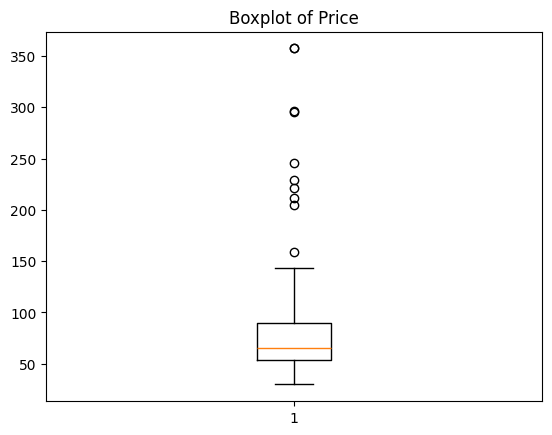

In [60]:
import matplotlib.pyplot as plt

plt.boxplot(df["price"])
plt.title("Boxplot of Price")
plt.show()

In [61]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -0.24249999999999972
Upper: 144.1975


In [62]:
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print("Outliers:", len(outliers))

Outliers: 10


In [63]:
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

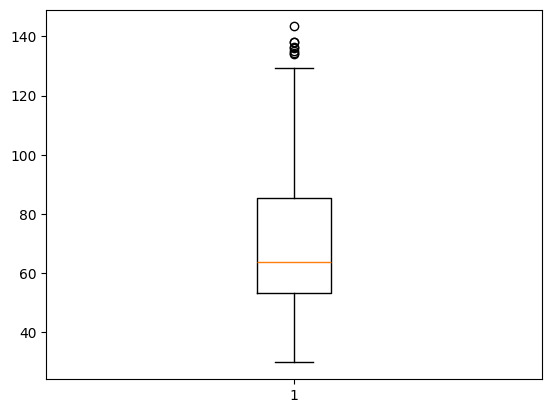

In [64]:
plt.boxplot(df["price"])
plt.show()

In [65]:
X = df.drop("price", axis=1)
y = df["price"]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Random Forest

In [67]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.337703703703712
RMSE: 17.02640751363875


In [70]:
import joblib

joblib.dump(model, "airbnb_model.pkl")

['airbnb_model.pkl']